# Pandas 프로젝트 - 실전 데이터 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform

# 한국어 폰트 설정
system = platform.system()
if system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'Noto Sans CJK JP'

# 음수 기호 표시
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 기초 프로젝트: 판매 데이터 분석

**문제:** 판매 데이터를 읽고 기본 통계를 계산하세요.

데이터 확인:
        Date Product  Quantity  Price Region
0 2024-01-01       A        11    100  North
1 2024-01-02       B         3    150  North
2 2024-01-03       C         6    150   West
3 2024-01-04       A         3    150   West
4 2024-01-05       B         5    100   East
5 2024-01-06       A        11    100   East
6 2024-01-07       B        15    100  South
7 2024-01-08       C         7    200   West
8 2024-01-09       A        14    150   West
9 2024-01-10       B        12    100  South

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      30 non-null     datetime64[ns]
 1   Product   30 non-null     object        
 2   Quantity  30 non-null     int32         
 3   Price     30 non-null     int32         
 4   Region    30 non-null     object        
dtypes: datetime64[ns](1), int32(2), object(2)
memory usage: 1.1

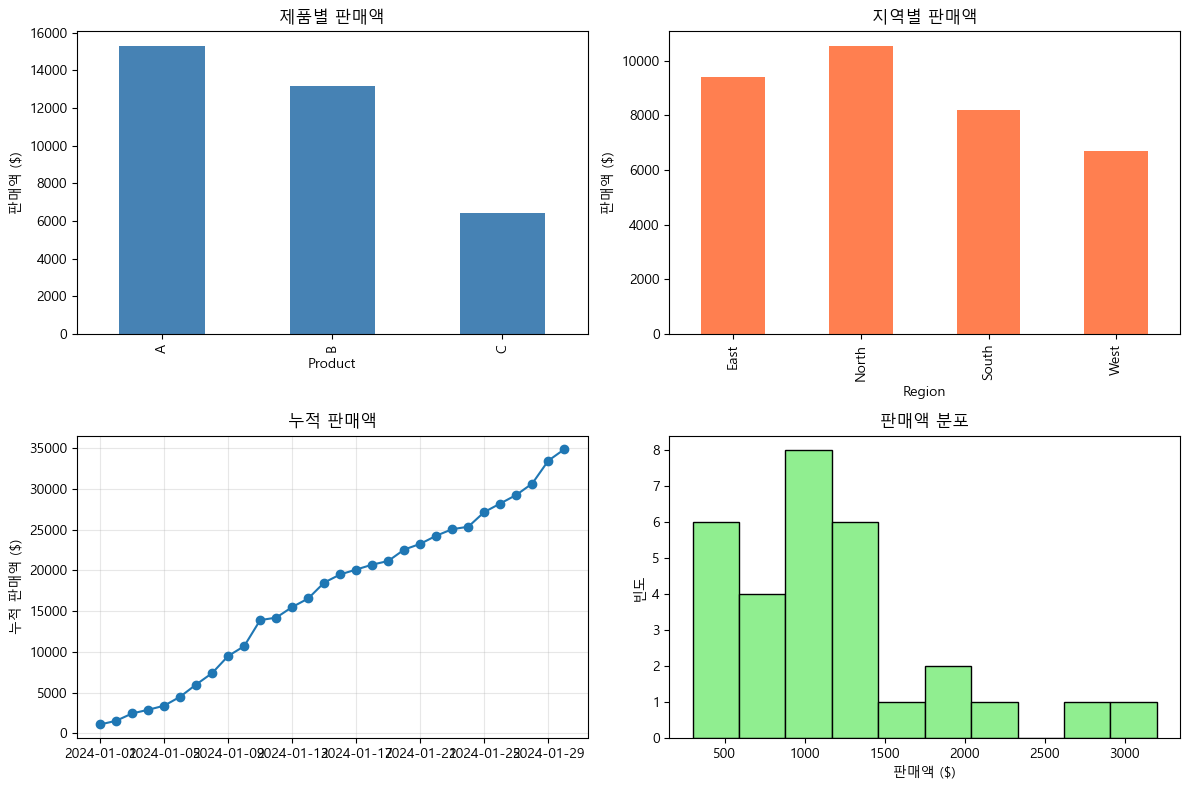

In [2]:
# 판매 데이터 생성
sales_data = pd.DataFrame({
    'Date': pd.date_range('2024-01-01', periods=30, freq='D'),
    'Product': ['A', 'B', 'C', 'A', 'B'] * 6,
    'Quantity': np.random.randint(1, 20, 30),
    'Price': np.random.choice([100, 200, 150], 30),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], 30)
})

print('데이터 확인:')
print(sales_data.head(10))

print('\n데이터 정보:')
print(sales_data.info())

print('\n기본 통계:')
print(sales_data.describe())

# 판매액 계산
sales_data['Sales'] = sales_data['Quantity'] * sales_data['Price']

print('\n총 판매액: ${:,.2f}'.format(sales_data['Sales'].sum()))
print('평균 판매액: ${:,.2f}'.format(sales_data['Sales'].mean()))
print('최대 판매액: ${:,.2f}'.format(sales_data['Sales'].max()))
print('최소 판매액: ${:,.2f}'.format(sales_data['Sales'].min()))

# 제품별 판매액
print('\n제품별 판매액:')
print(sales_data.groupby('Product')['Sales'].sum())

# 지역별 판매액
print('\n지역별 판매액:')
print(sales_data.groupby('Region')['Sales'].sum().sort_values(ascending=False))

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sales_data.groupby('Product')['Sales'].sum().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('제품별 판매액')
axes[0, 0].set_ylabel('판매액 ($)')

sales_data.groupby('Region')['Sales'].sum().plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('지역별 판매액')
axes[0, 1].set_ylabel('판매액 ($)')

axes[1, 0].plot(sales_data['Date'], sales_data['Sales'].cumsum(), marker='o')
axes[1, 0].set_title('누적 판매액')
axes[1, 0].set_ylabel('누적 판매액 ($)')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(sales_data['Sales'], bins=10, color='lightgreen', edgecolor='black')
axes[1, 1].set_title('판매액 분포')
axes[1, 1].set_xlabel('판매액 ($)')
axes[1, 1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

# 중급 프로젝트: 학생 성적 데이터베이스 관리

**문제:** 학생 데이터를 관리하고 여러 기준으로 필터링하세요.

전체 학생 데이터:
    StudentID     Name Department   GPA  Score  Attendance
0        1001    Alice         CS  2.75     91          89
1        1002      Bob       Math  3.90     77          97
2        1003  Charlie    Physics  3.46     65          84
3        1004    David         CS  3.20     64          97
4        1005      Eve       Math  2.31     96          76
5        1006    Frank    Physics  2.31     93          81
6        1007    Grace         CS  2.12     52          98
7        1008    Henry       Math  3.73     86          77
8        1009     Iris    Physics  3.20     56          84
9        1010     Jack         CS  3.42     70          72
10       1011    Karen       Math  2.04     58          83
11       1012      Leo    Physics  3.94     88          86
12       1013     Mona         CS  3.66     67          73
13       1014     Neil       Math  2.42     53          87
14       1015   Olivia    Physics  2.36     74          77
15       1016    Peter         CS  2.37     6

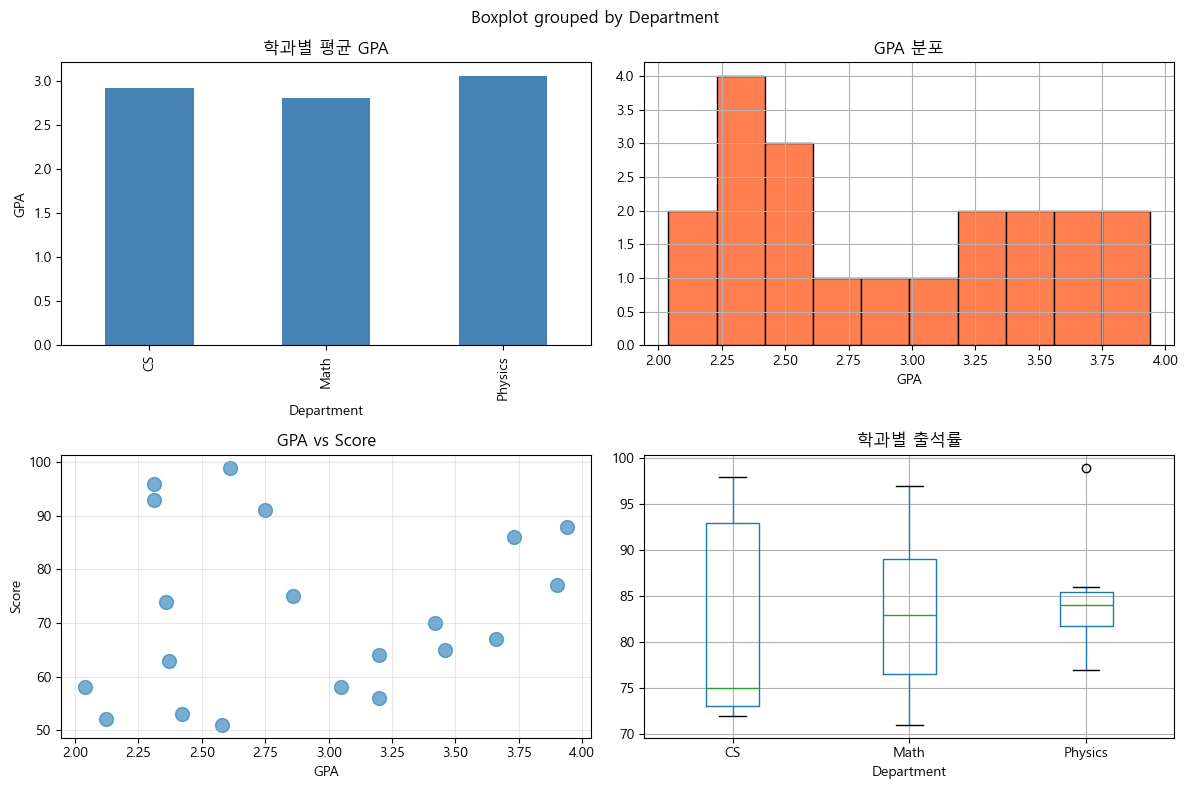

In [3]:
# 학생 데이터 생성
np.random.seed(42)
students = pd.DataFrame({
    'StudentID': range(1001, 1021),
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Henry', 'Iris', 'Jack',
             'Karen', 'Leo', 'Mona', 'Neil', 'Olivia', 'Peter', 'Quinn', 'Rachel', 'Sam', 'Tina'],
    'Department': ['CS', 'Math', 'Physics', 'CS', 'Math', 'Physics', 'CS', 'Math', 'Physics', 'CS',
                   'Math', 'Physics', 'CS', 'Math', 'Physics', 'CS', 'Math', 'Physics', 'CS', 'Math'],
    'GPA': np.round(np.random.uniform(2.0, 4.0, 20), 2),
    'Score': np.random.randint(50, 100, 20),
    'Attendance': np.random.randint(70, 100, 20)
})

print('전체 학생 데이터:')
print(students)

# 학과별 통계
print('\n학과별 GPA 통계:')
dept_stats = students.groupby('Department').agg({
    'GPA': ['mean', 'min', 'max', 'std'],
    'Score': ['mean', 'min', 'max'],
    'Attendance': 'mean'
})
print(dept_stats)

# GPA 우수 학생 (3.5 이상)
print('\nGPA 우수 학생 (3.5 이상):')
excellent = students[students['GPA'] >= 3.5]
print(excellent[['Name', 'Department', 'GPA', 'Score']])

# 성적 부진 학생 (70 미만)
print('\n성적 부진 학생 (70 미만):')
poor = students[students['Score'] < 70]
print(poor[['Name', 'Department', 'Score', 'Attendance']])

# 다중 조건 필터링
print('\nCS 학과 학생 중 GPA 3.0 이상 및 출석률 80% 이상:')
filtered = students[(students['Department'] == 'CS') & 
                    (students['GPA'] >= 3.0) & 
                    (students['Attendance'] >= 80)]
print(filtered[['Name', 'GPA', 'Attendance']])

# 순위 매기기
students['GPA_Rank'] = students['GPA'].rank(ascending=False, method='min')
students['Score_Rank'] = students['Score'].rank(ascending=False, method='min')

print('\n상위 5명:')
print(students.nsmallest(5, 'GPA_Rank')[['Name', 'GPA', 'GPA_Rank', 'Score', 'Score_Rank']])

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

students.groupby('Department')['GPA'].mean().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('학과별 평균 GPA')
axes[0, 0].set_ylabel('GPA')

students['GPA'].hist(bins=10, ax=axes[0, 1], color='coral', edgecolor='black')
axes[0, 1].set_title('GPA 분포')
axes[0, 1].set_xlabel('GPA')

axes[1, 0].scatter(students['GPA'], students['Score'], s=100, alpha=0.6)
axes[1, 0].set_xlabel('GPA')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('GPA vs Score')
axes[1, 0].grid(alpha=0.3)

students.boxplot(column='Attendance', by='Department', ax=axes[1, 1])
axes[1, 1].set_title('학과별 출석률')

plt.tight_layout()
plt.show()

# 상급 프로젝트: 시계열 데이터 분석 (주식 데이터)

**문제:** 주식 데이터를 분석하고 거래 신호를 생성하세요.

주식 데이터 확인:
                 Close   Volume
Date                           
2024-01-01  100.993428  4280143
2024-01-02  100.714153  1406716
2024-01-03  102.018781  3543590
2024-01-04  105.126334  4699391
2024-01-05  104.634020  3762174
2024-01-06  104.144046  1541252
2024-01-07  107.433358  2686293
2024-01-08  109.082320  3349916
2024-01-09  108.058093  3812150
2024-01-10  109.230653  4612610
                Close   Volume
Date                          
2024-08-30  93.737702  1248683
2024-08-31  95.360780  4380405
2024-09-01  93.071556  1026790
2024-09-02  92.448905  2691738
2024-09-03  91.570742  3908873
2024-09-04  90.374225  1448345
2024-09-05  93.565256  1749074
2024-09-06  94.323100  4633190
2024-09-07  91.944491  4685501
2024-09-08  93.632338  2879490

기술적 지표 계산 완료
                Close     SMA_20     SMA_50  Daily_Return  Volatility
Date                                                                 
2024-09-04  90.374225  93.687989  92.830270     -1.306658    1.828579
2024-09-0

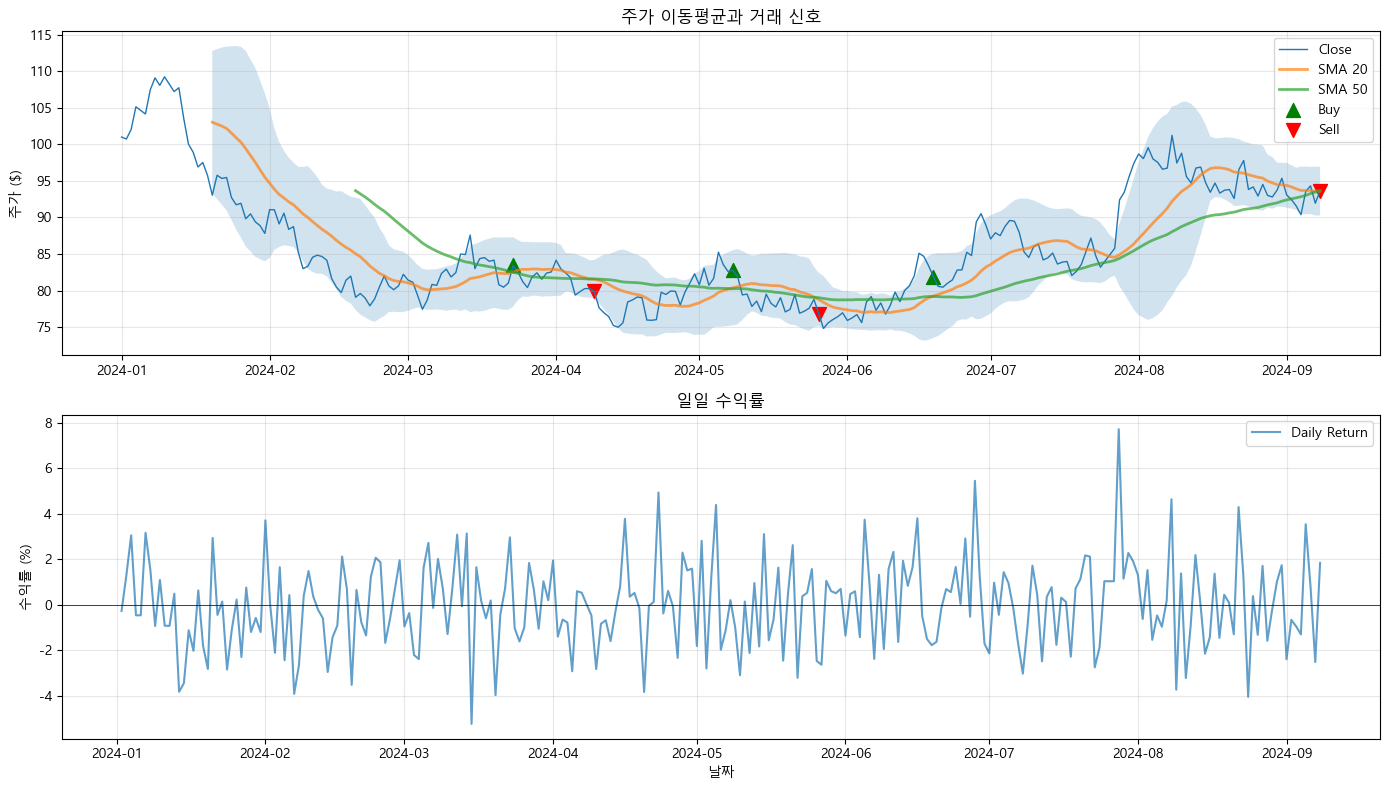

In [4]:
# 주식 데이터 생성
np.random.seed(42)
dates = pd.date_range('2024-01-01', periods=252, freq='D')
prices = 100 * np.cumprod(1 + np.random.randn(252) * 0.02)

stock_data = pd.DataFrame({
    'Date': dates,
    'Close': prices,
    'Volume': np.random.randint(1000000, 5000000, 252)
})

stock_data.set_index('Date', inplace=True)

print('주식 데이터 확인:')
print(stock_data.head(10))
print(stock_data.tail(10))

# 기술적 지표 계산
stock_data['SMA_20'] = stock_data['Close'].rolling(window=20).mean()  # 20일 이동평균
stock_data['SMA_50'] = stock_data['Close'].rolling(window=50).mean()  # 50일 이동평균
stock_data['Daily_Return'] = stock_data['Close'].pct_change() * 100  # 일일 수익률
stock_data['Volatility'] = stock_data['Daily_Return'].rolling(window=20).std()  # 변동성

# 상단/하단 밴드 (Bollinger Bands)
stock_data['Upper_Band'] = stock_data['SMA_20'] + (2 * stock_data['Close'].rolling(window=20).std())
stock_data['Lower_Band'] = stock_data['SMA_20'] - (2 * stock_data['Close'].rolling(window=20).std())

print('\n기술적 지표 계산 완료')
print(stock_data[['Close', 'SMA_20', 'SMA_50', 'Daily_Return', 'Volatility']].tail())

# 거래 신호 생성 (Golden Cross)
stock_data['Signal'] = 0
stock_data.loc[stock_data['SMA_20'] > stock_data['SMA_50'], 'Signal'] = 1  # 매수 신호
stock_data.loc[stock_data['SMA_20'] <= stock_data['SMA_50'], 'Signal'] = -1  # 매도 신호

# 신호 변화 감지
stock_data['Position'] = stock_data['Signal'].diff()
buy_signals = stock_data[stock_data['Position'] == 2]
sell_signals = stock_data[stock_data['Position'] == -2]

print(f'\n매수 신호: {len(buy_signals)}개')
print(buy_signals[['Close', 'SMA_20', 'SMA_50']].head())

print(f'\n매도 신호: {len(sell_signals)}개')
print(sell_signals[['Close', 'SMA_20', 'SMA_50']].head())

# 성능 지표
print(f'\n기간: {stock_data.index[0].date()} ~ {stock_data.index[-1].date()}')
print(f'초기 가격: ${stock_data["Close"].iloc[0]:.2f}')
print(f'최종 가격: ${stock_data["Close"].iloc[-1]:.2f}')
print(f'수익률: {(stock_data["Close"].iloc[-1] - stock_data["Close"].iloc[0]) / stock_data["Close"].iloc[0] * 100:.2f}%')
print(f'최대값: ${stock_data["Close"].max():.2f}')
print(f'최소값: ${stock_data["Close"].min():.2f}')
print(f'평균 수익률: {stock_data["Daily_Return"].mean():.4f}%')
print(f'변동성: {stock_data["Daily_Return"].std():.4f}%')

# 시각화
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(stock_data.index, stock_data['Close'], label='Close', linewidth=1)
plt.plot(stock_data.index, stock_data['SMA_20'], label='SMA 20', linewidth=2, alpha=0.7)
plt.plot(stock_data.index, stock_data['SMA_50'], label='SMA 50', linewidth=2, alpha=0.7)
plt.fill_between(stock_data.index, stock_data['Upper_Band'], stock_data['Lower_Band'], alpha=0.2)

# 매수/매도 신호 표시
plt.scatter(buy_signals.index, buy_signals['Close'], color='green', marker='^', s=100, label='Buy')
plt.scatter(sell_signals.index, sell_signals['Close'], color='red', marker='v', s=100, label='Sell')

plt.ylabel('주가 ($)')
plt.title('주가 이동평균과 거래 신호')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(stock_data.index, stock_data['Daily_Return'], label='Daily Return', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.ylabel('수익률 (%)')
plt.xlabel('날짜')
plt.title('일일 수익률')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/pandas_10_77.png', dpi=300, bbox_inches='tight')
plt.show()

# 고급 프로젝트: 다중 데이터 소스 병합 및 예측 분석

**문제:** 여러 데이터 소스를 병합하고 판매 예측을 수행하세요.

병합된 데이터:
   Product_ID       Date  Sales Product_Name Category  Price  Marketing_Cost
0         101 2024-01-01    202          상품A       전자  50000           33483
1         102 2024-01-02    448          상품B       의류  30000           27159
2         103 2024-01-03    370          상품C       식품  20000           24541
3         101 2024-01-04    206          상품A       전자  50000           45920
4         102 2024-01-05    171          상품B       의류  30000           36531
5         103 2024-01-06    288          상품C       식품  20000           11585
6         101 2024-01-07    120          상품A       전자  50000           13943
7         102 2024-01-08    202          상품B       의류  30000           33939
8         103 2024-01-09    221          상품C       식품  20000           29457
9         101 2024-01-10    314          상품A       전자  50000           11021

일일 분석:
             Revenue  Marketing_Cost  Sales            ROI
Date                                                      
2024-01-01  101000

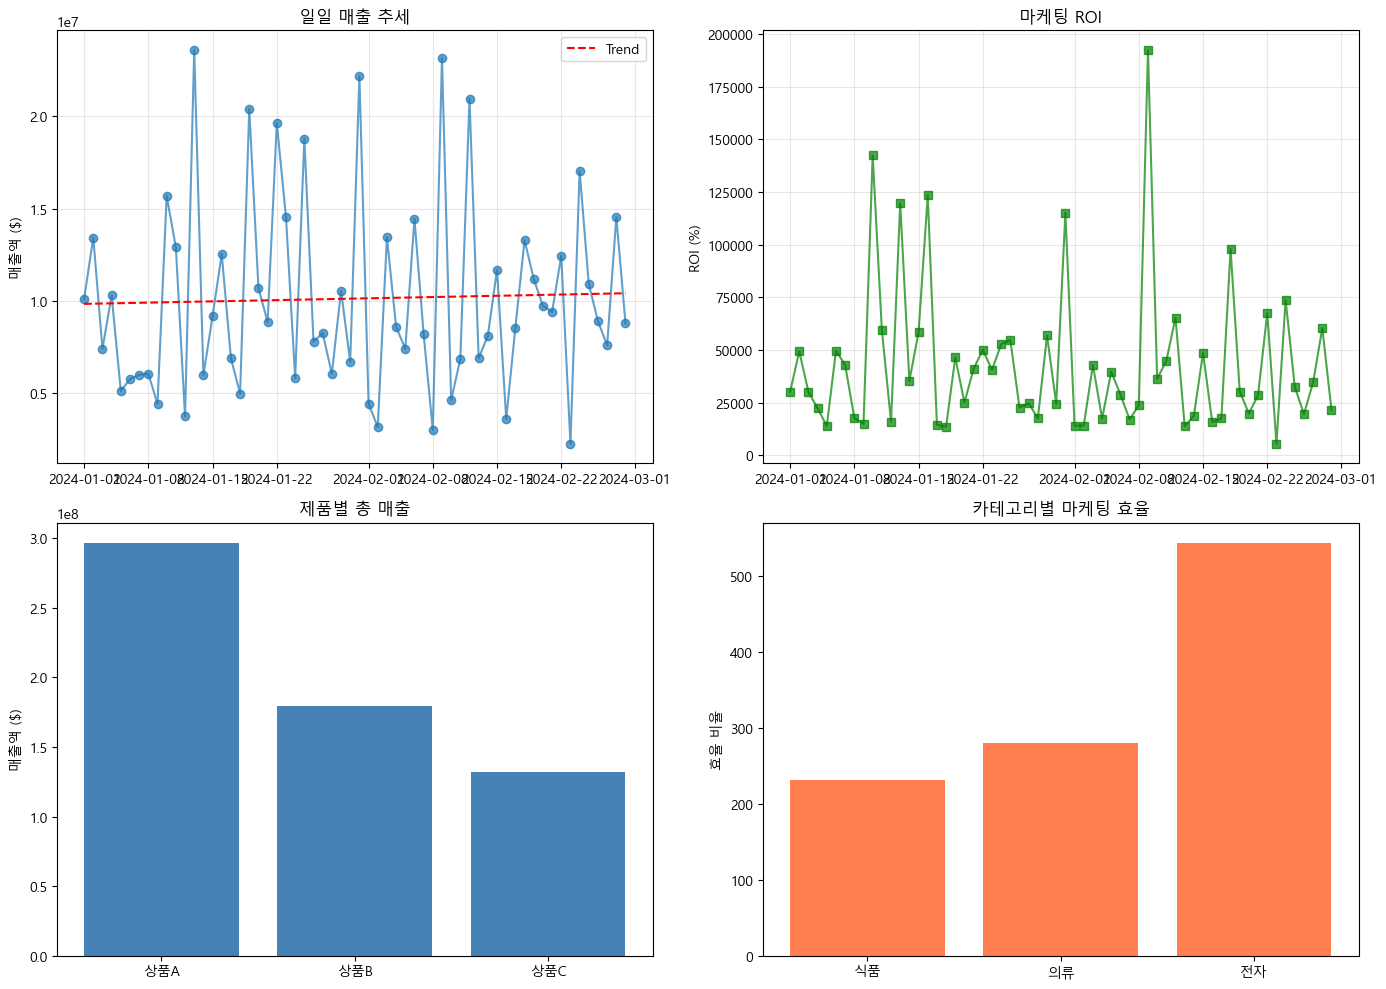

In [5]:
# 데이터 소스 1: 판매 기록
np.random.seed(42)
sales_df = pd.DataFrame({
    'Product_ID': [101, 102, 103, 101, 102, 103] * 10,
    'Date': pd.date_range('2024-01-01', periods=60, freq='D'),
    'Sales': np.random.randint(100, 500, 60)
})

# 데이터 소스 2: 제품 정보
product_df = pd.DataFrame({
    'Product_ID': [101, 102, 103],
    'Product_Name': ['상품A', '상품B', '상품C'],
    'Category': ['전자', '의류', '식품'],
    'Price': [50000, 30000, 20000]
})

# 데이터 소스 3: 마케팅 지출
marketing_df = pd.DataFrame({
    'Date': pd.date_range('2024-01-01', periods=60, freq='D'),
    'Marketing_Cost': np.random.randint(10000, 50000, 60)
})

# 데이터 병합
merged_df = sales_df.merge(product_df, on='Product_ID')
merged_df = merged_df.merge(marketing_df, on='Date')

print('병합된 데이터:')
print(merged_df.head(10))

# 매출액 계산
merged_df['Revenue'] = merged_df['Sales'] * merged_df['Price']

# 마케팅 효율성
daily_analysis = merged_df.groupby('Date').agg({
    'Revenue': 'sum',
    'Marketing_Cost': 'first',
    'Sales': 'sum'
})

daily_analysis['ROI'] = (daily_analysis['Revenue'] - daily_analysis['Marketing_Cost']) / daily_analysis['Marketing_Cost'] * 100

print('\n일일 분석:')
print(daily_analysis.head(10))

# 제품별 성과
product_performance = merged_df.groupby('Product_Name').agg({
    'Revenue': ['sum', 'mean'],
    'Sales': ['sum', 'mean'],
    'Price': 'first'
})

print('\n제품별 성과:')
print(product_performance)

# 카테고리별 분석
category_analysis = merged_df.groupby('Category').agg({
    'Revenue': 'sum',
    'Sales': 'sum',
    'Marketing_Cost': 'mean'
})

category_analysis['Conversion_Rate'] = category_analysis['Sales'] / category_analysis['Marketing_Cost'] * 100

print('\n카테고리별 분석:')
print(category_analysis)

# 간단한 예측 (추세 분석)
from scipy import stats
x = np.arange(len(daily_analysis))
y = daily_analysis['Revenue'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
trend_line = slope * x + intercept

print(f'\n판매 추세 분석:')
print(f'기울기: {slope:.2f} (일일 증가액)')
print(f'R² 값: {r_value**2:.4f}')
print(f'30일 예측 매출: ${trend_line[-1] + slope * 30:.2f}')

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 일일 매출
axes[0, 0].plot(daily_analysis.index, daily_analysis['Revenue'], marker='o', alpha=0.7)
axes[0, 0].plot(daily_analysis.index, trend_line, 'r--', label='Trend')
axes[0, 0].set_title('일일 매출 추세')
axes[0, 0].set_ylabel('매출액 ($)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 마케팅 ROI
axes[0, 1].plot(daily_analysis.index, daily_analysis['ROI'], marker='s', color='green', alpha=0.7)
axes[0, 1].set_title('마케팅 ROI')
axes[0, 1].set_ylabel('ROI (%)')
axes[0, 1].grid(alpha=0.3)

# 제품별 매출
product_sales = merged_df.groupby('Product_Name')['Revenue'].sum()
axes[1, 0].bar(product_sales.index, product_sales.values, color='steelblue')
axes[1, 0].set_title('제품별 총 매출')
axes[1, 0].set_ylabel('매출액 ($)')

# 카테고리별 마케팅 효율
category_roi = merged_df.groupby('Category')['Revenue'].sum() / merged_df.groupby('Category')['Marketing_Cost'].sum()
axes[1, 1].bar(category_roi.index, category_roi.values, color='coral')
axes[1, 1].set_title('카테고리별 마케팅 효율')
axes[1, 1].set_ylabel('효율 비율')

plt.tight_layout()
plt.show()